In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
print("IPython: Thread limits set to 4")

IPython: Thread limits set to 4


In [2]:
# train_graphsage_node_fixed.py
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

NODE_CSV  = "GNNDatasets/node.csv"
EDGE_CSV  = "GNNDatasets/node_edges.csv"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ----------------------------- Load nodes -----------------------------
nodes_df = pd.read_csv(NODE_CSV)

label_col = None
for cand in ["label", "is_trojan", "trojan", "target"]:
    if cand in nodes_df.columns:
        label_col = cand; break
if label_col is None:
    nodes_df["label"] = nodes_df["circuit_name"].astype(str).str.contains("__trojan_").astype(int)
    label_col = "label"

nodes_df["uid"] = nodes_df["circuit_name"].astype(str) + "::" + nodes_df["node"].astype(str)

feat_df = nodes_df.copy()
if "gate_type" in feat_df.columns:
    gate_oh = pd.get_dummies(feat_df["gate_type"], prefix="gt")
    feat_df = pd.concat([feat_df.drop(columns=["gate_type"]), gate_oh], axis=1)

exclude = {"uid","node","circuit_name",label_col}
num_cols = [c for c in feat_df.columns if c not in exclude and pd.api.types.is_numeric_dtype(feat_df[c])]
X = feat_df[num_cols].fillna(0.0).values.astype(np.float32)
y = nodes_df[label_col].values.astype(np.int64)

# ----------------------------- Load edges; add missing nodes -----------------------------
edges_df = pd.read_csv(EDGE_CSV)
edges_df["src_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["src"].astype(str)
edges_df["dst_uid"] = edges_df["circuit_name"].astype(str) + "::" + edges_df["dst"].astype(str)

known_uids = set(nodes_df["uid"])
edge_uids = set(edges_df["src_uid"]).union(set(edges_df["dst_uid"]))
missing = list(edge_uids - known_uids)

if missing:
    zero_row = np.zeros((1, X.shape[1]), dtype=np.float32)
    addX = np.repeat(zero_row, len(missing), axis=0)
    addY = -1*np.ones(len(missing), dtype=np.int64)
    add_df = pd.DataFrame({
        "uid": missing,
        "circuit_name": [u.split("::",1)[0] for u in missing],
        "node": [u.split("::",1)[1] for u in missing],
        label_col: addY
    })
    X = np.vstack([X, addX])
    y = np.concatenate([y, addY])
    nodes_df = pd.concat([nodes_df, add_df], ignore_index=True)

uid_to_idx = {u:i for i,u in enumerate(nodes_df["uid"].tolist())}
src_idx = edges_df["src_uid"].map(uid_to_idx).dropna().astype(int).values
dst_idx = edges_df["dst_uid"].map(uid_to_idx).dropna().astype(int).values
edge_index = np.stack([np.concatenate([src_idx, dst_idx]),
                       np.concatenate([dst_idx, src_idx])], axis=0)

# ----------------------------- Scale features -----------------------------
labeled_mask_np = (y >= 0)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[labeled_mask_np] = scaler.fit_transform(X_scaled[labeled_mask_np])
if (~labeled_mask_np).any():
    X_scaled[~labeled_mask_np] = (X_scaled[~labeled_mask_np] - scaler.mean_) / np.sqrt(scaler.var_ + 1e-8)

# ----------------------------- Splits -----------------------------
idx_all = np.where(labeled_mask_np)[0]
y_all = y[labeled_mask_np]

idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

# ----------------------------- Torch tensors -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X_scaled).to(device)
y_t = torch.from_numpy(y).to(device)

edge_index_t = torch.from_numpy(edge_index).long().to(device)

train_mask_t = torch.zeros(len(y), dtype=torch.bool, device=device); train_mask_t[idx_train] = True
val_mask_t   = torch.zeros(len(y), dtype=torch.bool, device=device); val_mask_t[idx_val]   = True
test_mask_t  = torch.zeros(len(y), dtype=torch.bool, device=device); test_mask_t[idx_test]  = True
labeled_mask_t = torch.from_numpy(labeled_mask_np).to(device)

# ----------------------------- Build GraphSAGE neighborhood aggregation -----------------------------
def aggregate_neighbors(x, edge_index):
    src, dst = edge_index
    num_nodes = x.size(0)
    agg = torch.zeros_like(x)
    agg.index_add_(0, dst, x[src])
    deg = torch.bincount(dst, minlength=num_nodes).clamp(min=1).unsqueeze(1).float()
    return agg / deg

class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim * 2, out_dim)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.lin.weight)
    def forward(self, x, edge_index):
        neigh = aggregate_neighbors(x, edge_index)
        h = torch.cat([x, neigh], dim=1)
        h = self.dropout(h)
        return self.lin(h)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid_dim=96, out_dim=2, dropout=0.35):
        super().__init__()
        self.s1 = GraphSAGELayer(in_dim, hid_dim, dropout)
        self.s2 = GraphSAGELayer(hid_dim, out_dim, dropout)
        self.do = nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = F.relu(self.s1(x, edge_index))
        x = self.do(x)
        x = self.s2(x, edge_index)
        return x

model = GraphSAGE(in_dim=X_t.size(1), hid_dim=96, out_dim=2, dropout=0.35).to(device)

# ----------------------------- Loss, optimizer -----------------------------
train_labels = y_t[train_mask_t]
classes, counts = torch.unique(train_labels, return_counts=True)
num_pos = counts[classes==1].item() if (classes==1).any() else 1
num_neg = counts[classes==0].item() if (classes==0).any() else 1
weight_pos = (num_neg + num_pos) / (2.0 * num_pos)
weight_neg = (num_neg + num_pos) / (2.0 * num_neg)
class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)

# ----------------------------- Training -----------------------------
def evaluate(mask_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t, edge_index_t)
        pred = logits.argmax(dim=1)
        msk = mask_t & (y_t >= 0)
        if msk.sum() == 0: return 0.0
        return (pred[msk] == y_t[msk]).float().mean().item()

best_val, best_state = -1.0, None
patience, patience_cnt = 20, 0
EPOCHS = 300

for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_t, edge_index_t)
    loss = criterion(logits[train_mask_t], y_t[train_mask_t])
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 2.0)
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        val_acc = evaluate(val_mask_t)
        test_acc = evaluate(test_mask_t)
        print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Val {val_acc:.4f} | Test {test_acc:.4f}")
        if val_acc > best_val + 1e-4:
            best_val = val_acc
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("Early stopping."); break

if best_state is not None:
    model.load_state_dict(best_state)

# ----------------------------- Final eval -----------------------------
model.eval()
with torch.no_grad():
    logits = model(X_t, edge_index_t)
    preds = logits.argmax(dim=1)

msk = (test_mask_t & (y_t >= 0)).cpu().numpy()
y_true = y_t.cpu().numpy()[msk]
y_pred = preds.cpu().numpy()[msk]

acc = (y_true == y_pred).mean()
print("\nFinal Evaluation (Node-Level)")
print("=============================")
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=[0,1], target_names=["clean","trojan"], digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=[0,1]))


Epoch 001 | Loss 0.8283 | Val 0.7232 | Test 0.7174
Epoch 010 | Loss 0.3688 | Val 0.9927 | Test 0.9929
Epoch 020 | Loss 0.1952 | Val 0.9966 | Test 0.9966
Epoch 030 | Loss 0.1183 | Val 1.0000 | Test 0.9999
Epoch 040 | Loss 0.0812 | Val 1.0000 | Test 0.9999
Epoch 050 | Loss 0.0591 | Val 1.0000 | Test 0.9999
Epoch 060 | Loss 0.0466 | Val 1.0000 | Test 0.9999
Epoch 070 | Loss 0.0389 | Val 1.0000 | Test 0.9999
Epoch 080 | Loss 0.0335 | Val 1.0000 | Test 0.9999
Epoch 090 | Loss 0.0298 | Val 1.0000 | Test 0.9999
Epoch 100 | Loss 0.0272 | Val 1.0000 | Test 0.9999
Epoch 110 | Loss 0.0253 | Val 1.0000 | Test 0.9999
Epoch 120 | Loss 0.0232 | Val 1.0000 | Test 0.9999
Epoch 130 | Loss 0.0209 | Val 1.0000 | Test 0.9999
Epoch 140 | Loss 0.0200 | Val 1.0000 | Test 0.9999
Epoch 150 | Loss 0.0188 | Val 1.0000 | Test 0.9999
Epoch 160 | Loss 0.0180 | Val 1.0000 | Test 0.9999
Epoch 170 | Loss 0.0171 | Val 1.0000 | Test 0.9999
Epoch 180 | Loss 0.0168 | Val 1.0000 | Test 1.0000
Epoch 190 | Loss 0.0158 | Val 1

#### Gradientattack under no defense.

Starting GBLA reconstruction attack (GraphSAGE)...
Attacking class 0: 20 nodes ...
attacking indices 47313
attacking indices 43842
attacking indices 12358
attacking indices 59547
attacking indices 51318
attacking indices 46519
attacking indices 7831
attacking indices 5444
attacking indices 40055
attacking indices 31492
attacking indices 26587
attacking indices 5244
attacking indices 27671
attacking indices 52459
attacking indices 5762
attacking indices 44957
attacking indices 48049
attacking indices 26937
attacking indices 42630
attacking indices 32257
Attacking class 1: 20 nodes ...
attacking indices 185678
attacking indices 200409
attacking indices 73570
attacking indices 225253
attacking indices 146955
attacking indices 204162
attacking indices 189851
attacking indices 91494
attacking indices 143103
attacking indices 96881
attacking indices 177195
attacking indices 89475
attacking indices 200770
attacking indices 126390
attacking indices 69088
attacking indices 152728
attacking indi

/tmp/ipykernel_2035/3120132482.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)
/tmp/ipykernel_2035/3120132482.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)
/tmp/ipykernel_2035/3120132482.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=ordered_classes, showfliers=False)



Boxplots saved to: reconstruction_errors_trojan_boxplot_sage.pdf


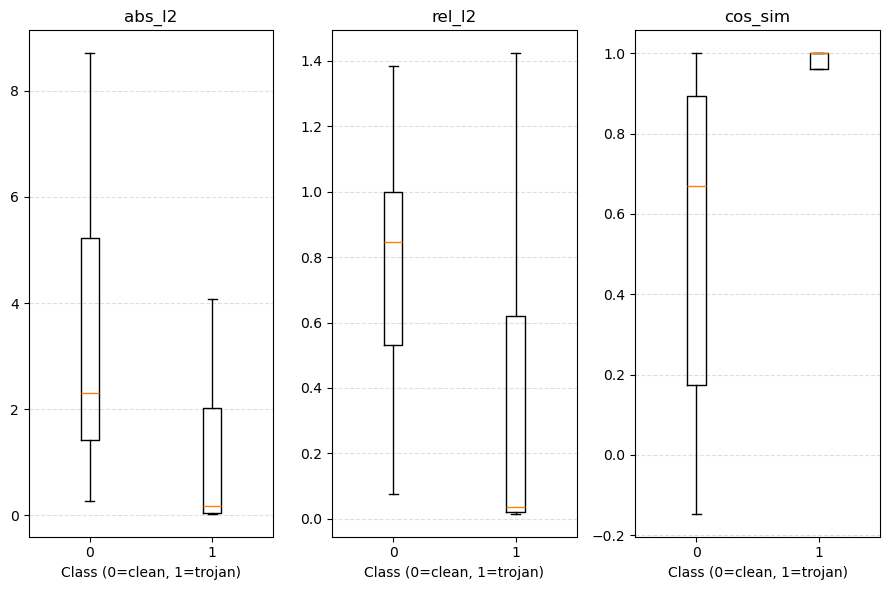

In [3]:
# gbla_trojan_recon_sage.py  (fixed: no A_t dependency)
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300
ATTACKS_PER_CLASS = 20
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42
SAVE_PLOT = "reconstruction_errors_trojan_boxplot_sage.pdf"

# Set seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# === Ensure environment is ready ===
required_names = ["model", "X_t", "y_t", "edge_index_t", "train_mask_t"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. "
                       f"Run this script after training GraphSAGE model.")

device = next(model.parameters()).device
model.eval()
for p in model.parameters():
    p.requires_grad = True

# === Prepare data ===
train_idx_all = torch.nonzero(train_mask_t & (y_t >= 0), as_tuple=False).view(-1).cpu().numpy().tolist()
train_labels = y_t[train_mask_t].cpu().numpy()
classes_present = np.unique(train_labels).tolist()
rng = np.random.default_rng(RANDOM_SEED)
features_orig = X_t.clone().detach()

# === Initialize metrics containers ===
metrics = {int(c): {"abs_l2": [], "rel_l2": [], "cos_sim": []} for c in classes_present}

# === Attack loop ===
print("Starting GBLA reconstruction attack (GraphSAGE)...")

for class_val in classes_present:
    candidate_indices = [int(idx) for idx in train_idx_all if int(y_t[idx].item()) == int(class_val)]
    if len(candidate_indices) == 0:
        print(f" - No candidates for class {class_val}; skipping.")
        continue

    if len(candidate_indices) <= ATTACKS_PER_CLASS:
        target_indices = candidate_indices
    else:
        target_indices = list(rng.choice(candidate_indices, size=ATTACKS_PER_CLASS, replace=False))

    print(f"Attacking class {class_val}: {len(target_indices)} nodes ...")

    for target_idx in target_indices:
        print(f'attacking indices {target_idx}')
        model.zero_grad()

        # --- Step 1: obtain true gradients ---
        logits = model(features_orig.to(device), edge_index_t)
        target_label = y_t[target_idx:target_idx+1].to(device)
        target_loss = nn.CrossEntropyLoss()(logits[target_idx:target_idx+1], target_label)
        target_loss.backward()

        target_grads = []
        for p in model.parameters():
            if p.grad is None:
                target_grads.append(torch.zeros_like(p))
            else:
                target_grads.append(p.grad.detach().clone())

        # --- Step 2: optimize dummy feature ---
        dummy_feat = torch.randn_like(features_orig[target_idx:target_idx+1],
                                      device=device, requires_grad=True)
        dummy_opt = optim.Adam([dummy_feat], lr=DUMMY_LR)

        for it in range(ATTACK_ITERATIONS):
            dummy_features = features_orig.clone().to(device)
            dummy_features[target_idx:target_idx+1] = dummy_feat

            model.zero_grad()
            dummy_logits = model(dummy_features, edge_index_t)
            dummy_loss = nn.CrossEntropyLoss()(dummy_logits[target_idx:target_idx+1], target_label)
            dummy_grads = torch.autograd.grad(dummy_loss,
                                              tuple(model.parameters()),
                                              create_graph=True, allow_unused=True)

            grad_diff_loss = torch.tensor(0.0, device=device)
            for dg, tg in zip(dummy_grads, target_grads):
                if dg is None:
                    dg = torch.zeros_like(tg)
                grad_diff_loss += torch.sum((dg - tg) ** 2)

            reg_loss = torch.norm(dummy_feat, p=2)
            total_loss = grad_diff_loss + L2_REG * reg_loss

            dummy_opt.zero_grad()
            total_loss.backward()
            dummy_opt.step()

        # --- Step 3: compute metrics ---
        orig_feat = features_orig[target_idx:target_idx+1].detach().cpu()
        recon_feat = dummy_feat.detach().cpu()

        abs_l2 = torch.norm(recon_feat - orig_feat, p=2).item()
        rel_l2 = abs_l2 / (torch.norm(orig_feat, p=2).item() + 1e-8)
        cos_sim = torch.nn.functional.cosine_similarity(recon_feat, orig_feat).mean().item()

        metrics[int(class_val)]["abs_l2"].append(abs_l2)
        metrics[int(class_val)]["rel_l2"].append(rel_l2)
        metrics[int(class_val)]["cos_sim"].append(cos_sim)

# === Summary ===
print("\nReconstruction error summary (GraphSAGE)")
print("==========================================")
for c, vals in metrics.items():
    for mname, mvals in vals.items():
        if len(mvals) == 0: continue
        arr = np.array(mvals)
        print(f" Class {c} | {mname}: mean={arr.mean():.4f}, std={arr.std():.4f}, median={np.median(arr):.4f}")

# === Boxplots ===
plt.figure(figsize=(9,6))
for i, mname in enumerate(["abs_l2", "rel_l2", "cos_sim"], start=1):
    plt.subplot(1,3,i)
    ordered_classes = sorted(metrics.keys())
    data = [metrics[c][mname] for c in ordered_classes]
    plt.boxplot(data, labels=ordered_classes, showfliers=False)
    plt.title(mname)
    plt.xlabel("Class (0=clean, 1=trojan)")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=200)
print(f"\nBoxplots saved to: {SAVE_PLOT}")
plt.show()


Starting multi-defense GBLA attack (GraphSAGE)...

--- Defense: none ---
  Class 0: 20 nodes


  Class 1: 20 nodes



--- Defense: dp ---
  Class 0: 20 nodes


  Class 1: 20 nodes



--- Defense: clip ---
  Class 0: 20 nodes


...


--- Defense: advtrain ---
  Class 0: 20 nodes


  Class 1: 20 nodes



Results saved to results_defenses_graphsage.csv (rows=240)

Summary (mean ± std):
            abs_l2                     rel_l2                   cos_sim  \
              mean        std count      mean       std count      mean   
defense                                                                   
advtrain  2.108063   1.900019    40  0.635627  0.562854    40  0.722227   
clip      2.166328   2.056247    40  0.712226  0.753681    40  0.645819   
dp        2.852892   2.375845    40  0.908117  0.706458    40  0.581645   
none      4.145096  11.658951    40  0.668586  0.658454    40  0.698196   
quant     3.062467   1.938062    40  1.013338  0.639594    40  0.603207   
secure    7.101759   4.801026    40  1.934448  0.915963    40  0.182525   

                          
               std count  
defense                   
advtrain  0.334428    40  
clip      0.455393    40  
dp        0.438967    40  
none      0.407379    40  
quant     0.329605    40  
secure    0.218985    40 

/tmp/ipykernel_2035/538801878.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=defenses, showfliers=False)



Boxplots saved to: reconstruction_defenses_boxplot_graphsage.pdf


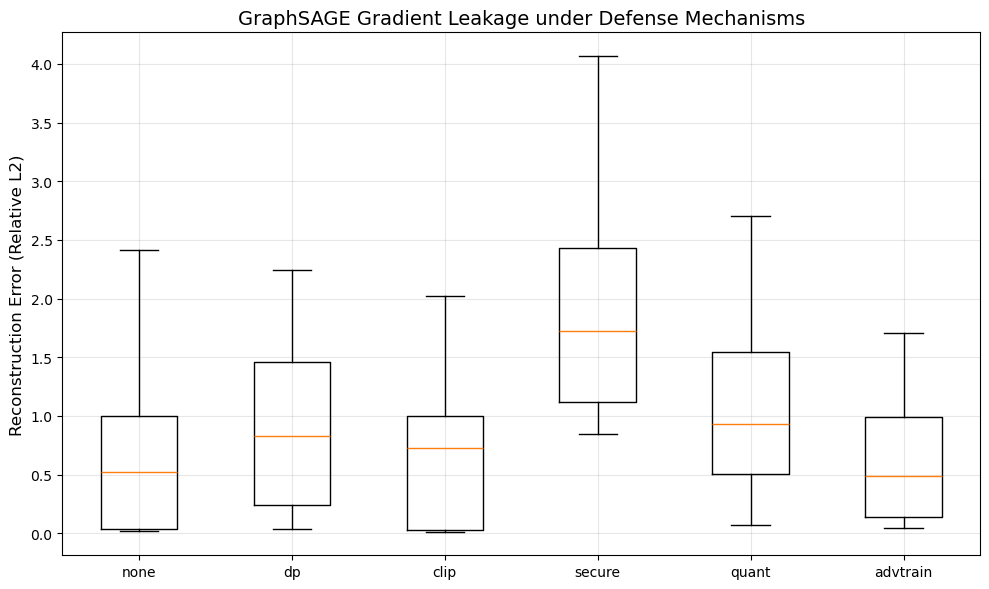

In [4]:
# ==================== CELL 3: Five Defense Strategies (GraphSAGE) ====================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# === ATTACK HYPERPARAMS ===
ATTACK_ITERATIONS = 300
ATTACKS_PER_CLASS = 20
DUMMY_LR = 0.1
L2_REG = 0.001
RANDOM_SEED = 42
SAVE_CSV = "results_defenses_graphsage.csv"
SAVE_PLOT = "reconstruction_defenses_boxplot_graphsage.pdf"

# Set seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# === Ensure environment ===
required_names = ["model", "X_t", "y_t", "edge_index_t", "train_mask_t"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. "
                       f"Run this script after training GraphSAGE model.")

device = next(model.parameters()).device
model.eval()
for p in model.parameters():
    p.requires_grad = True

# === Prepare dataset ===
train_idx_all = torch.nonzero(train_mask_t & (y_t >= 0), as_tuple=False).view(-1).cpu().numpy().tolist()
train_labels = y_t[train_mask_t].cpu().numpy()
classes_present = np.unique(train_labels).tolist()
rng = np.random.default_rng(RANDOM_SEED)
features_orig = X_t.clone().detach()

# === Define defense modifier ===
def apply_defense_to_grads(grads, defense):
    grads_mod = []
    for g in grads:
        if g is None:
            g = torch.zeros_like(grads[0])
        if defense == "dp":  # differential privacy
            g = g + 0.02 * torch.randn_like(g)
        elif defense == "clip":  # clipping
            g = torch.clamp(g, -0.5, 0.5)
        elif defense == "secure":  # secure aggregation
            g = torch.zeros_like(g)
        elif defense == "quant":  # quantization
            g = torch.round(g * 10) / 10
        elif defense == "advtrain":  # adversarial training noise
            g = g + 0.01 * torch.sign(torch.randn_like(g))
        grads_mod.append(g.detach())
    return grads_mod

# === Defenses to evaluate ===
defenses = ["none", "dp", "clip", "secure", "quant", "advtrain"]
results = []

print("Starting multi-defense GBLA attack (GraphSAGE)...")

# === Attack loop ===
for defense in defenses:
    print(f"\n--- Defense: {defense} ---")
    for class_val in classes_present:
        candidate_indices = [int(idx) for idx in train_idx_all if int(y_t[idx].item()) == int(class_val)]
        if len(candidate_indices) == 0:
            print(f" - No candidates for class {class_val}; skipping.")
            continue
        if len(candidate_indices) <= ATTACKS_PER_CLASS:
            target_indices = candidate_indices
        else:
            target_indices = list(rng.choice(candidate_indices, size=ATTACKS_PER_CLASS, replace=False))

        print(f"  Class {class_val}: {len(target_indices)} nodes")

        for target_idx in tqdm(target_indices, desc=f"{defense} | Class {class_val}", leave=False):
            model.zero_grad()

            # --- Step 1: True gradients ---
            logits = model(features_orig.to(device), edge_index_t)
            target_label = y_t[target_idx:target_idx+1].to(device)
            target_loss = nn.CrossEntropyLoss()(logits[target_idx:target_idx+1], target_label)
            target_loss.backward()

            target_grads = []
            for p in model.parameters():
                if p.grad is None:
                    target_grads.append(torch.zeros_like(p))
                else:
                    target_grads.append(p.grad.detach().clone())

            # --- Step 2: Apply defense ---
            grads_used = target_grads if defense == "none" else apply_defense_to_grads(target_grads, defense)

            # --- Step 3: Optimize dummy feature ---
            dummy_feat = torch.randn_like(features_orig[target_idx:target_idx+1],
                                          device=device, requires_grad=True)
            dummy_opt = optim.Adam([dummy_feat], lr=DUMMY_LR)

            for it in range(ATTACK_ITERATIONS):
                dummy_features = features_orig.clone().to(device)
                dummy_features[target_idx:target_idx+1] = dummy_feat

                model.zero_grad()
                dummy_logits = model(dummy_features, edge_index_t)
                dummy_loss = nn.CrossEntropyLoss()(dummy_logits[target_idx:target_idx+1], target_label)

                dummy_grads = torch.autograd.grad(dummy_loss, tuple(model.parameters()),
                                                  create_graph=True, allow_unused=True)

                grad_diff_loss = torch.tensor(0.0, device=device)
                for dg, tg in zip(dummy_grads, grads_used):
                    if dg is None:
                        dg = torch.zeros_like(tg)
                    grad_diff_loss += torch.sum((dg - tg) ** 2)

                reg_loss = torch.norm(dummy_feat, p=2)
                total_loss = grad_diff_loss + L2_REG * reg_loss

                dummy_opt.zero_grad()
                total_loss.backward()
                dummy_opt.step()

            # --- Step 4: Compute metrics ---
            orig_feat = features_orig[target_idx:target_idx+1].detach().cpu()
            recon_feat = dummy_feat.detach().cpu()
            abs_l2 = torch.norm(recon_feat - orig_feat, p=2).item()
            rel_l2 = abs_l2 / (torch.norm(orig_feat, p=2).item() + 1e-8)
            cos_sim = F.cosine_similarity(recon_feat, orig_feat).mean().item()

            results.append({
                "defense": defense,
                "class": int(class_val),
                "node_idx": int(target_idx),
                "abs_l2": abs_l2,
                "rel_l2": rel_l2,
                "cos_sim": cos_sim
            })

# === Save results ===
df_def = pd.DataFrame(results)
df_def.to_csv(SAVE_CSV, index=False)
print(f"\nResults saved to {SAVE_CSV} (rows={len(df_def)})")

# === Summary ===
print("\nSummary (mean ± std):")
summary = df_def.groupby("defense")[["abs_l2", "rel_l2", "cos_sim"]].agg(["mean", "std", "count"])
print(summary)

# === Boxplots ===
plt.figure(figsize=(10,6))
data = [df_def[df_def["defense"]==d]["rel_l2"].values for d in defenses]
plt.boxplot(data, labels=defenses, showfliers=False)
plt.ylabel("Reconstruction Error (Relative L2)", fontsize=12)
plt.title("GraphSAGE Gradient Leakage under Defense Mechanisms", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=200)
print(f"\nBoxplots saved to: {SAVE_PLOT}")
plt.show()


In [5]:
# === Per-class Summary ===
print("\nDetailed per-class summary (mean ± std):")
class_summary = (
    df_def.groupby(["defense", "class"])[["abs_l2", "rel_l2", "cos_sim"]]
    .agg(["mean", "std", "count"])
    .reset_index()
)

for d in defenses:
    print(f"\n--- Defense: {d} ---")
    for c in sorted(df_def["class"].unique()):
        sub = class_summary[(class_summary["defense"] == d) & (class_summary["class"] == c)]
        if sub.empty:
            print(f"  Class {c}: No data")
            continue
        row = sub.iloc[0]
        cname = "clean" if c == 0 else "trojan"
        print(f"  {cname:7s} | abs_l2 = {row[('abs_l2','mean')]:.4f} ± {row[('abs_l2','std')]:.4f} "
              f"| rel_l2 = {row[('rel_l2','mean')]:.4f} ± {row[('rel_l2','std')]:.4f} "
              f"| cos_sim = {row[('cos_sim','mean')]:.4f} ± {row[('cos_sim','std')]:.4f} "
              f"(n={int(row[('abs_l2','count')])})")



Detailed per-class summary (mean ± std):

--- Defense: none ---
  clean   | abs_l2 = 3.3363 ± 2.4491 | rel_l2 = 0.8491 ± 0.5109 | cos_sim = 0.5022 ± 0.4538 (n=20)
  trojan  | abs_l2 = 4.9539 ± 16.4815 | rel_l2 = 0.4881 ± 0.7485 | cos_sim = 0.8942 ± 0.2320 (n=20)

--- Defense: dp ---
  clean   | abs_l2 = 4.6866 ± 1.8191 | rel_l2 = 1.4142 ± 0.4816 | cos_sim = 0.2187 ± 0.3333 (n=20)
  trojan  | abs_l2 = 1.0192 ± 1.0948 | rel_l2 = 0.4020 ± 0.5032 | cos_sim = 0.9445 ± 0.0847 (n=20)

--- Defense: clip ---
  clean   | abs_l2 = 3.3405 ± 1.3472 | rel_l2 = 1.0176 ± 0.3975 | cos_sim = 0.3814 ± 0.4584 (n=20)
  trojan  | abs_l2 = 0.9922 ± 1.9904 | rel_l2 = 0.4068 ± 0.9009 | cos_sim = 0.9103 ± 0.2614 (n=20)

--- Defense: secure ---
  clean   | abs_l2 = 5.5691 ± 2.2878 | rel_l2 = 1.3025 ± 0.3876 | cos_sim = 0.1923 ± 0.2067 (n=20)
  trojan  | abs_l2 = 8.6344 ± 6.0938 | rel_l2 = 2.5663 ± 0.8551 | cos_sim = 0.1728 ± 0.2356 (n=20)

--- Defense: quant ---
  clean   | abs_l2 = 4.2443 ± 1.6803 | rel_l2 = 1